# Commodity Price Indices — FRED Data

Download and visualise commodity price indices from the Federal Reserve Economic Database (FRED). We track eight raw-material indicators from 2021 onwards.

**Indicators:**
- `PCU32733273` — Cement and Concrete Product Manufacturing
- `PIORECRUSDM` — Global price of Iron Ore
- `PCOPPUSDM` — Global price of Copper
- `PALUMUSDM` — Global price of Aluminum
- `POILBREUSDM` — Global price of Brent Crude
- `WPU07` — Producer Price Index: Rubber and Plastic Products
- `WPS061` — Producer Price Index: Industrial Chemicals
- `PCU3253132531` — Producer Price Index: Fertilizer Manufacturing

**R original used:** tidyquant, showtext, ggtext, GGally  
**Python equivalents:** pandas_datareader / requests, pandas, seaborn, matplotlib

In [19]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date
import warnings
warnings.filterwarnings('ignore')

import requests
from dotenv import load_dotenv
import os

load_dotenv()
fred_api_key = os.getenv('FRED_API_KEY')


sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

In [ ]:
# --- Define the FRED indicator codes and their human-readable labels ---

indicator_labels = {
    'PCU32733273':   'Cement',
    'PIORECRUSDM':   'Iron Ore',
    'PCOPPUSDM':     'Copper',
    'PALUMUSDM':     'Aluminum',
    'POILBREUSDM':   'Brent Crude',
    'WPU07':         'Rubber',
    'WPS061':        'Industrial Chemicals',
    'PCU3253132531': 'Fertilizer'
}

start_date = '2021-01-01'
end_date   = str(date.today())


Fetching FRED data from 2021-01-01 to 2026-03-20


In [20]:

print(f'Fetching FRED data from {start_date} to {end_date}')

load_dotenv()
fred_api_key = os.getenv('FRED_API_KEY')

def get_fred(series_id, start=None, end=None):
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = dict(
        series_id=series_id,
        api_key=fred_api_key,
        file_type='json',
        observation_start=start,
        observation_end=end
    )
    r = requests.get(url, params=params)
    df = pd.DataFrame(r.json()['observations'])[['date', 'value']]
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date')['value']

# Fetch all series and combine into one DataFrame
my_data = pd.concat(
    {label: get_fred(sid, start=start_date, end=end_date)
     for sid, label in indicator_labels.items()},
    axis=1
)

print(my_data.shape)
my_data.head()


Fetching FRED data from 2021-01-01 to 2026-03-20
(62, 8)


,Cement,Iron Ore,Copper,Aluminum,Brent Crude,Rubber,Industrial Chemicals,Fertilizer
date,,,,,,,,
2021-01-01,179.8,166.738095,7972.147500,2003.975500,55.224762,197.3,254.3,176.5
2021-02-01,181.2,162.325000,8470.940000,2078.593500,62.362500,198.6,270.7,185.6
2021-03-01,182.1,166.739130,8988.247826,2190.482609,65.796087,201.9,281.8,195.9
2021-04-01,184.9,178.250000,9324.817500,2319.392500,65.531818,207.6,292.2,204.2
2021-05-01,185.3,202.857143,10166.285000,2434.776500,68.375238,212.0,310.7,216.2


In [23]:
my_data_long = (
    my_data
    .reset_index()                          # bring 'date' back as a column
    .melt(id_vars='date',                   # keep date
          var_name='new_name',              # column names → 'new_name'
          value_name='price')               # values → 'price'
)

print(my_data_long.shape)
my_data_long.head()

(496, 3)


,date,new_name,price
0,2021-01-01,Cement,179.8
1,2021-02-01,Cement,181.2
2,2021-03-01,Cement,182.1
3,2021-04-01,Cement,184.9
4,2021-05-01,Cement,185.3


(496, 3)


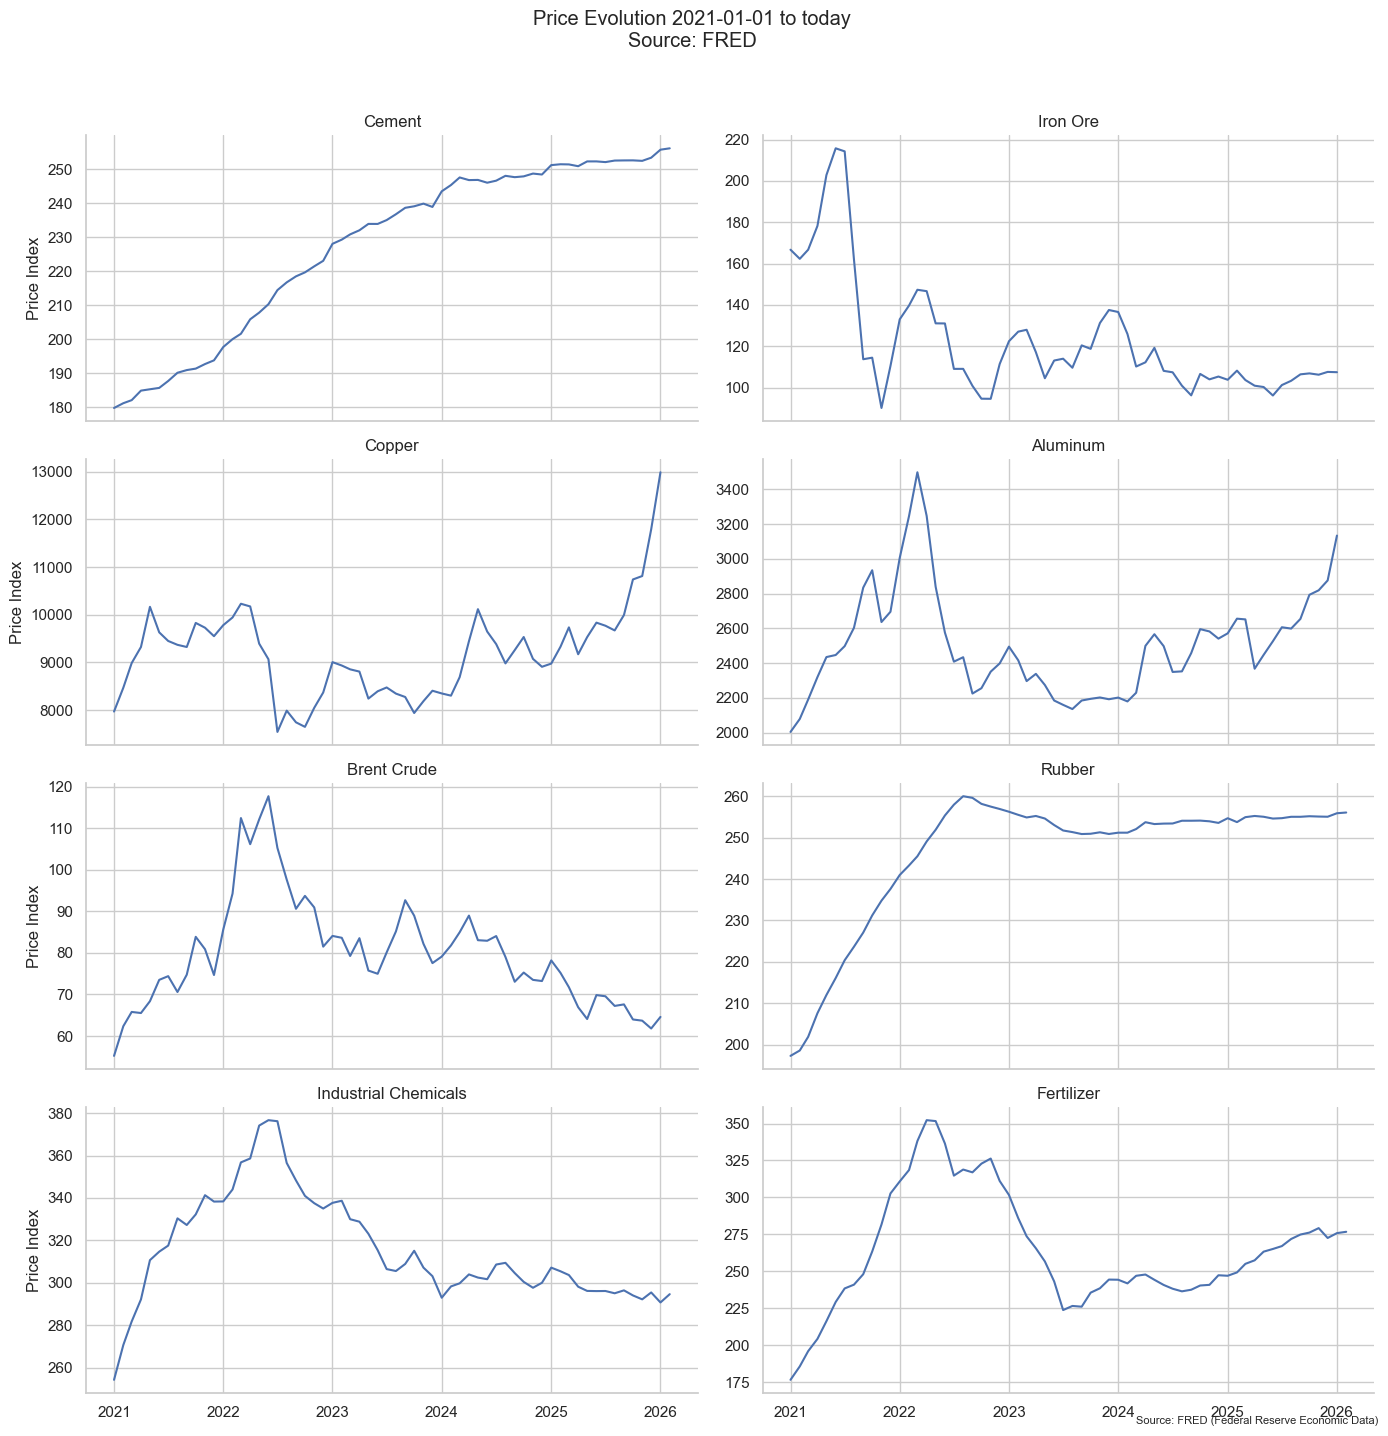

In [24]:
# --- Time series plot: raw price levels ---
# Each panel shows one indicator's actual price index

my_data_long = (
    my_data
    .reset_index()                          # bring 'date' back as a column
    .melt(id_vars='date',                   # keep date
          var_name='new_name',              # column names → 'new_name'
          value_name='price')               # values → 'price'
)

print(my_data_long.shape)
my_data_long.head()


g = sns.FacetGrid(
    my_data_long,
    col='new_name',
    col_wrap=2,
    sharey=False,       # free y-scales: each commodity has different units
    sharex=True,
    height=3.5, aspect=2
)
g.map(sns.lineplot, 'date', 'price')
g.set_axis_labels('', 'Price Index')
g.set_titles('{col_name}')
g.figure.suptitle(f'Price Evolution {start_date} to today\nSource: FRED', y=1.02)
plt.figtext(0.99, 0.01, 'Source: FRED (Federal Reserve Economic Data)', ha='right', fontsize=8)
plt.tight_layout()
plt.show()

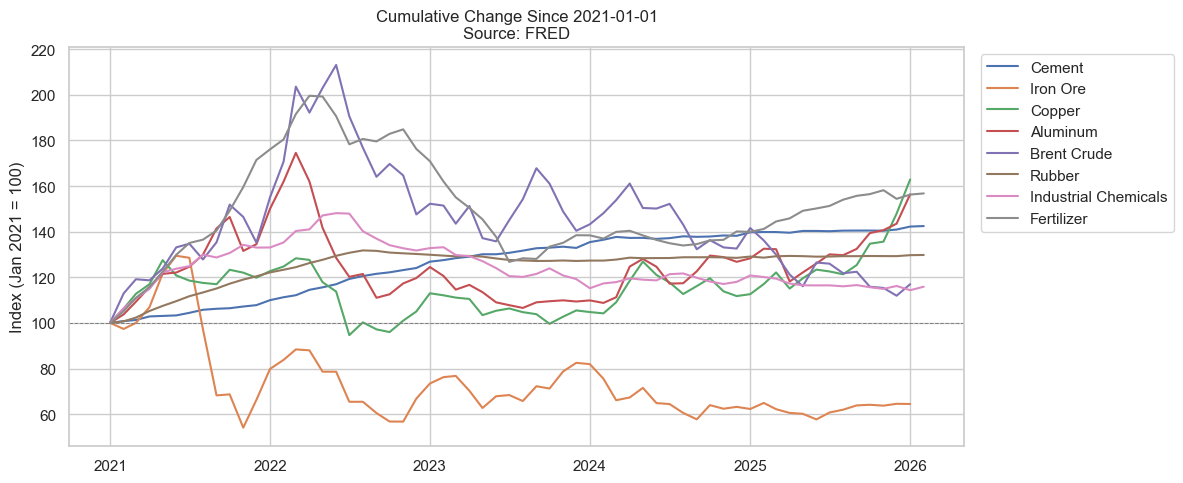

In [27]:
# --- Faceted cumulative change (delta) plot ---
# delta = current price / first price; so 0% line = starting level
# Shows how each commodity has moved relative to Jan 2021

my_data_long['delta'] = (
    my_data_long
    .groupby('new_name')['price']
    .transform(lambda x: x / x.iloc[0] * 100)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=my_data_long,
    x='date',
    y='delta',
    hue='new_name',
    ax=ax
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.axhline(100, color='grey', linestyle='--', linewidth=0.7)
ax.set_xlabel('')
ax.set_ylabel('Index (Jan 2021 = 100)')
ax.legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title(f'Cumulative Change Since {start_date}\nSource: FRED')
plt.tight_layout()
plt.show()

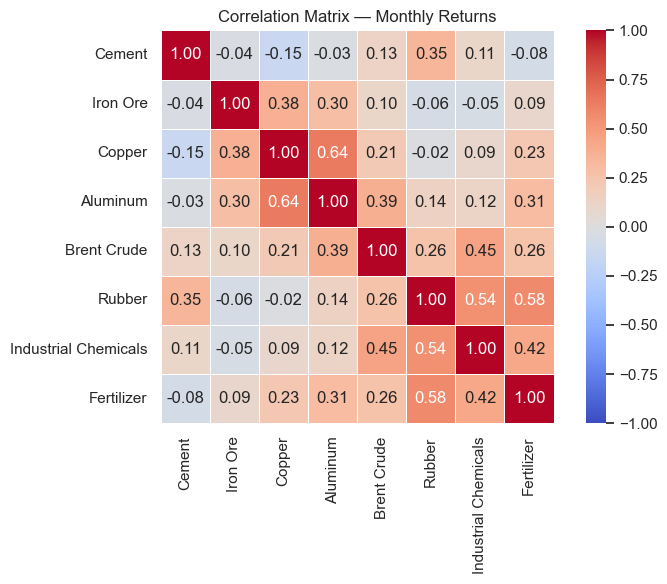

In [34]:
# ---   Correlation Matrix ---
 
# Monthly % changes, drop the first NaN row
my_data_returns = my_data.pct_change().dropna()

corr = my_data_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Monthly Returns')
plt.tight_layout()
plt.show()
